### Explanation for Cell 1This cell executes: `import numpy as np`, `import matplotlib.pyplot as plt`, and `import tensorflow as tf`.This explanation cell was added to describe what was done in the next cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from sklearn.metrics import classification_report, accuracy_score
from collections import deque
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

X_train = np.load("../processed_data/X_train.npy").astype("float32")
X_test = np.load("../processed_data/X_test.npy").astype("float32")
y_train = np.load("../processed_data/y_train.npy").astype("int64")
y_test = np.load("../processed_data/y_test.npy").astype("int64")

if X_train.max() > 1.0:
    X_train = X_train / 255.0
    X_test = X_test / 255.0

num_classes = 10
class_names = [f"c{i}" for i in range(num_classes)]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (17939, 64, 64, 3) X_test: (4485, 64, 64, 3)
y_train: (17939,) y_test: (4485,)


### Explanation for Cell 2This cell executes: `class DriverClassificationEnv:`, `def __init__(self, X, y, episode_length=32):`, and `self.X = X`.This explanation cell was added to describe what was done in the next cell.

In [2]:
# True RL setup: turn classification samples into a sequential episodic environment.
# state = image, action = class prediction, reward = +1 / -1, next_state = next image
class DriverClassificationEnv:
    def __init__(self, X, y, episode_length=32):
        self.X = X
        self.y = y
        self.episode_length = episode_length
        self.n = len(X)
        self.t = 0
        self.idx = None

    def reset(self):
        self.t = 0
        self.idx = np.random.randint(0, self.n)
        return self.X[self.idx]

    def step(self, action):
        label = self.y[self.idx]
        reward = 1.0 if int(action) == int(label) else -1.0

        self.t += 1
        done = self.t >= self.episode_length

        self.idx = np.random.randint(0, self.n)
        next_state = self.X[self.idx]
        return next_state, reward, done, {"label": int(label)}


def reward_fn(actions, labels):
    return np.where(actions == labels, 1.0, -1.0).astype("float32")

### Explanation for Cell 3This cell executes: `def build_q_network(input_shape=(64, 64, 3), n_actions=10):`, `model = tf.keras.Sequential([`, and `layers.Input(shape=input_shape),`.This explanation cell was added to describe what was done in the next cell.

In [5]:
def build_q_network(input_shape=(64, 64, 3), n_actions=10):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_actions)  # Q(s, a)
    ])
    return model

q_net = build_q_network(input_shape=X_train.shape[1:], n_actions=num_classes)
target_q_net = build_q_network(input_shape=X_train.shape[1:], n_actions=num_classes)
target_q_net.set_weights(q_net.get_weights())

optimizer = tf.keras.optimizers.Adam(1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

# DQN hyperparameters
gamma = 0.95             # discount factor
alpha = 1e-3             # learning rate proxy (optimizer step size)
epsilon = 1.0            # initial exploration
epsilon_min = 0.10
epsilon_decay = 0.995
batch_size = 64
buffer_size = 20_000
warmup_steps = 500
train_steps = 10000
target_update_freq = 250
eval_freq = 500

replay_buffer = deque(maxlen=buffer_size)
train_env = DriverClassificationEnv(X_train, y_train, episode_length=32)

def epsilon_greedy_action(state, eps):
    if np.random.rand() < eps:
        return np.random.randint(num_classes)
    q_values = q_net(np.expand_dims(state, axis=0), training=False)[0].numpy()
    return int(np.argmax(q_values))

def sample_replay(buffer, size):
    batch = random.sample(buffer, size)
    states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
    return (
        states.astype("float32"),
        actions.astype("int64"),
        rewards.astype("float32"),
        next_states.astype("float32"),
        dones.astype("float32")
    )

@tf.function
def dqn_train_step(states, actions, rewards, next_states, dones):
    next_q = target_q_net(next_states, training=False)
    max_next_q = tf.reduce_max(next_q, axis=1)
    targets = rewards + gamma * (1.0 - dones) * max_next_q

    with tf.GradientTape() as tape:
        q_values = q_net(states, training=True)
        action_mask = tf.one_hot(actions, depth=num_classes)
        pred_q = tf.reduce_sum(q_values * action_mask, axis=1)
        loss = loss_fn(targets, pred_q)

    grads = tape.gradient(loss, q_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, q_net.trainable_variables))
    return loss

def evaluate_policy(model, X, y):
    q_vals = model.predict(X, verbose=0)
    preds = np.argmax(q_vals, axis=1)
    return float(np.mean(preds == y))

# Warmup replay memory
state = train_env.reset()
for _ in range(warmup_steps):
    action = np.random.randint(num_classes)
    next_state, reward, done, _ = train_env.step(action)
    replay_buffer.append((state, action, reward, next_state, done))
    state = train_env.reset() if done else next_state

history_rl = {"train_loss": [], "episode_reward": [], "val_acc": [], "epsilon": []}

state = train_env.reset()
ep_reward = 0.0

for step in range(1, train_steps + 1):
    action = epsilon_greedy_action(state, epsilon)
    next_state, reward, done, _ = train_env.step(action)
    replay_buffer.append((state, action, reward, next_state, done))

    states_b, actions_b, rewards_b, next_states_b, dones_b = sample_replay(replay_buffer, batch_size)
    loss = dqn_train_step(states_b, actions_b, rewards_b, next_states_b, dones_b)
    history_rl["train_loss"].append(float(loss.numpy()))

    ep_reward += reward
    state = train_env.reset() if done else next_state

    if done:
        history_rl["episode_reward"].append(ep_reward)
        ep_reward = 0.0

    if step % target_update_freq == 0:
        target_q_net.set_weights(q_net.get_weights())

    if step % eval_freq == 0:
        val_acc = evaluate_policy(q_net, X_test, y_test)
        history_rl["val_acc"].append(val_acc)
        history_rl["epsilon"].append(epsilon)
        print(f"Step {step:5d} | Loss {history_rl['train_loss'][-1]:.4f} | Val acc {val_acc:.4f} | eps {epsilon:.3f}")

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

reward_history = history_rl["episode_reward"]
acc_history = history_rl["val_acc"]

Step   500 | Loss 0.3936 | Val acc 0.1075 | eps 0.100
Step  1000 | Loss 0.3220 | Val acc 0.1871 | eps 0.100
Step  1500 | Loss 0.4497 | Val acc 0.2448 | eps 0.100
Step  2000 | Loss 0.4677 | Val acc 0.2241 | eps 0.100
Step  2500 | Loss 0.5823 | Val acc 0.3050 | eps 0.100
Step  3000 | Loss 1.1007 | Val acc 0.3411 | eps 0.100
Step  3500 | Loss 0.9057 | Val acc 0.3895 | eps 0.100
Step  4000 | Loss 0.5940 | Val acc 0.4328 | eps 0.100
Step  4500 | Loss 0.8590 | Val acc 0.4809 | eps 0.100
Step  5000 | Loss 0.7081 | Val acc 0.5402 | eps 0.100
Step  5500 | Loss 0.4055 | Val acc 0.5944 | eps 0.100
Step  6000 | Loss 0.3570 | Val acc 0.6696 | eps 0.100
Step  6500 | Loss 0.4326 | Val acc 0.7242 | eps 0.100
Step  7000 | Loss 0.3611 | Val acc 0.7001 | eps 0.100
Step  7500 | Loss 0.3976 | Val acc 0.7581 | eps 0.100
Step  8000 | Loss 0.5376 | Val acc 0.7980 | eps 0.100
Step  8500 | Loss 0.7571 | Val acc 0.8147 | eps 0.100
Step  9000 | Loss 0.4268 | Val acc 0.8428 | eps 0.100
Step  9500 | Loss 1.0992 | V

### Explanation for Cell 4This cell executes: `q_test = q_net.predict(X_test, verbose=0)`, `y_pred = np.argmax(q_test, axis=1)`, and `test_acc = accuracy_score(y_test, y_pred)`.This explanation cell was added to describe what was done in the next cell.

In [6]:
q_test = q_net.predict(X_test, verbose=0)
y_pred = np.argmax(q_test, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"RL agent test accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names))

RL agent test accuracy: 0.8566
              precision    recall  f1-score   support

          c0       0.89      0.79      0.84       498
          c1       0.95      0.92      0.93       453
          c2       0.75      0.93      0.83       464
          c3       0.93      0.90      0.91       469
          c4       0.74      0.86      0.80       465
          c5       0.86      0.98      0.92       463
          c6       0.83      0.92      0.87       465
          c7       0.98      0.83      0.90       400
          c8       0.84      0.73      0.78       382
          c9       0.89      0.67      0.77       426

    accuracy                           0.86      4485
   macro avg       0.87      0.85      0.85      4485
weighted avg       0.86      0.86      0.86      4485



### Explanation for Cell 5This cell executes: `plt.figure(figsize=(14, 4))`, `plt.subplot(1, 3, 1)`, and `plt.plot(history_rl["train_loss"], label="Train TD loss")`.This explanation cell was added to describe what was done in the next cell.

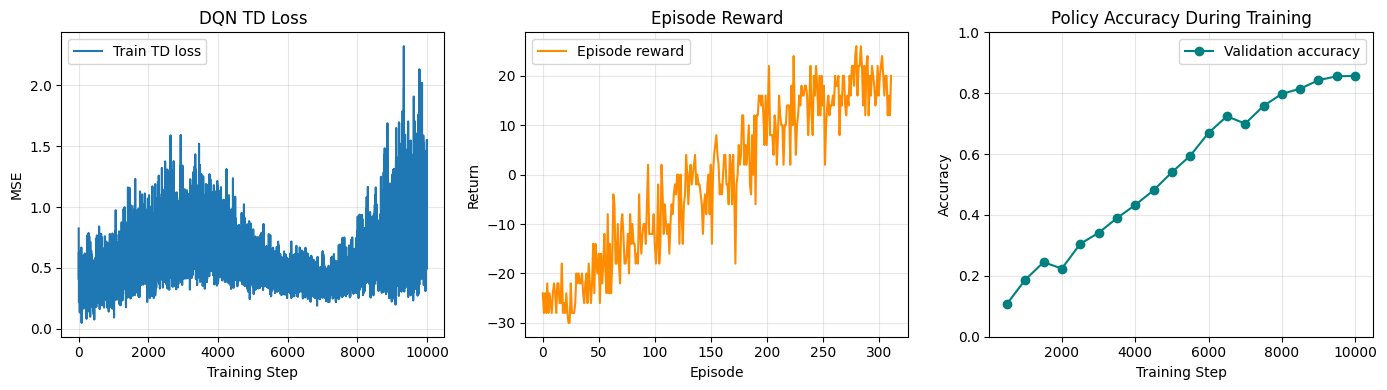

In [7]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history_rl["train_loss"], label="Train TD loss")
plt.title("DQN TD Loss")
plt.xlabel("Training Step")
plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
if len(history_rl["episode_reward"]) > 0:
    plt.plot(history_rl["episode_reward"], color="darkorange", label="Episode reward")
plt.title("Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
if len(history_rl["val_acc"]) > 0:
    eval_steps = np.arange(1, len(history_rl["val_acc"]) + 1) * eval_freq
    plt.plot(eval_steps, history_rl["val_acc"], marker="o", color="teal", label="Validation accuracy")
plt.ylim(0, 1)
plt.title("Policy Accuracy During Training")
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Explanation for Cell 6This cell executes: `def predict_image_array(img_array, model=q_net):`, `x = img_array.astype("float32")`, and `if x.max() > 1.0:`.This explanation cell was added to describe what was done in the next cell.

In [8]:
def predict_image_array(img_array, model=q_net):
    x = img_array.astype("float32")
    if x.max() > 1.0:
        x = x / 255.0
    x = np.expand_dims(x, axis=0)

    q_vals = model.predict(x, verbose=0)[0]
    pred_class = int(np.argmax(q_vals))
    return pred_class, q_vals

def predict_image_path(img_path, model=q_net, target_size=(64, 64)):
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    arr = tf.keras.utils.img_to_array(img)
    pred_class, q_vals = predict_image_array(arr, model=model)

    plt.figure(figsize=(4, 4))
    plt.imshow(arr.astype("uint8"))
    plt.title(f"Predicted: {class_names[pred_class]}")
    plt.axis("off")
    plt.show()

    print("Predicted class:", class_names[pred_class])
    print("Q-values:", np.round(q_vals, 3))
    return pred_class, q_vals

### Explanation for Cell 7This cell executes: `sample_idx = 0`, `sample_image = X_test[sample_idx]`, and `sample_true = y_test[sample_idx]`.This explanation cell was added to describe what was done in the next cell.

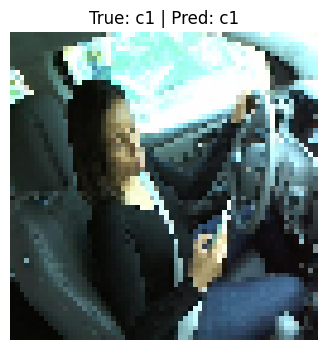

Top-3 predicted classes:
1. c1 (Q=5.060)
2. c6 (Q=3.854)
3. c3 (Q=3.852)


In [9]:
# Example prediction using one test image
sample_idx = 0
sample_image = X_test[sample_idx]
sample_true = y_test[sample_idx]

pred_class, q_vals = predict_image_array(sample_image)

plt.figure(figsize=(4, 4))
plt.imshow((sample_image * 255).astype("uint8") if sample_image.max() <= 1 else sample_image.astype("uint8"))
plt.title(f"True: {class_names[sample_true]} | Pred: {class_names[pred_class]}")
plt.axis("off")
plt.show()

print("Top-3 predicted classes:")
top3 = np.argsort(q_vals)[-3:][::-1]
for rank, cls in enumerate(top3, start=1):
    print(f"{rank}. {class_names[cls]} (Q={q_vals[cls]:.3f})")

# To predict an external image file, uncomment and change path:
# predict_image_path(r"../dataset/imgs/train/c0/img_1.jpg")

### Explanation for Cell 8This cell executes: `from sklearn.metrics import confusion_matrix, roc_curve, auc`, `from sklearn.preprocessing import label_binarize`, and `import seaborn as sns`.This explanation cell was added to describe what was done in the next cell.

Saved RL model to: ../models/rl_q_model.keras


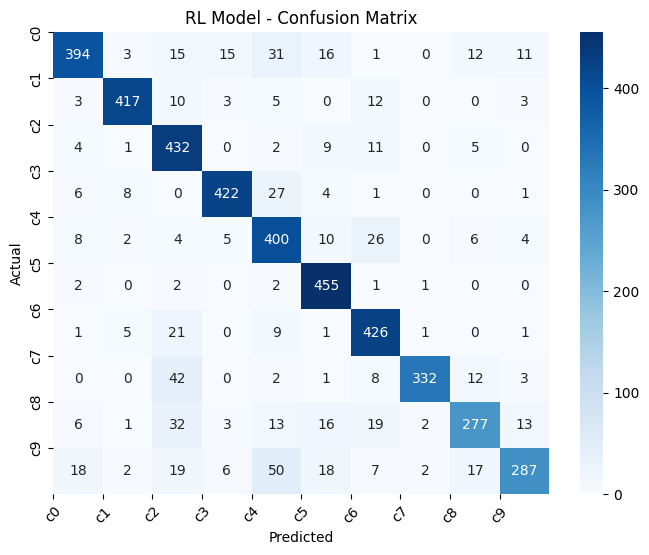

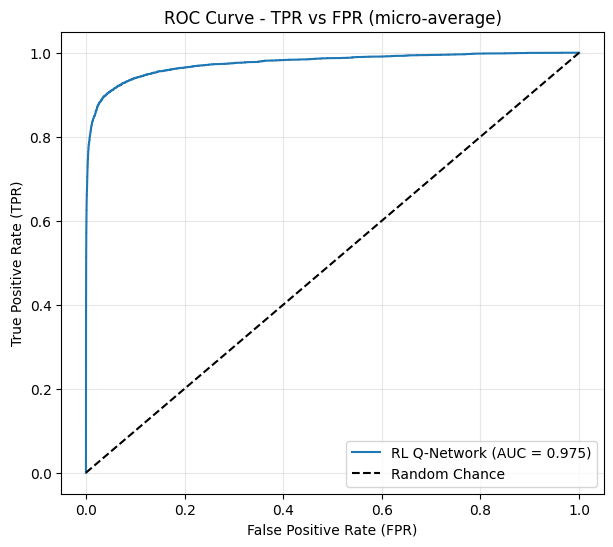

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
# 1) Save model
model_save_path = "../models/rl_q_model.keras"
q_net.save(model_save_path)
print(f"Saved RL model to: {model_save_path}")

# 2) Predict test set and confusion matrix
q_test = q_net.predict(X_test, verbose=0)
y_pred = np.argmax(q_test, axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("RL Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.show()

# 3) ROC curve (micro-average)
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
q_scores = tf.nn.softmax(q_test, axis=1).numpy()
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), q_scores.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"RL Q-Network (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.title("ROC Curve - TPR vs FPR (micro-average)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Explanation for Cell 9This markdown cell introduces the section: **DQN Reinforcement Learning Notebook Summary**.This explanation cell was added to describe what was done in the next cell.

# DQN Reinforcement Learning Notebook Summary

## What We Did

- Implemented a **true DQN training loop** for distracted-driver states (`c0` to `c9`).
- Loaded processed image arrays from `../processed_data` (`X_train`, `X_test`, `y_train`, `y_test`).
- Built two CNN Q-networks:
  - **Online network** for learning
  - **Target network** for stable Bellman targets
- Defined a sequential episodic environment where each step returns:
  - current image state
  - reward (`+1` for correct action, `-1` for incorrect)
  - next image state
  - done flag at episode end
- Added DQN essentials:
  - discount factor **gamma**
  - exploration with **epsilon-greedy** policy and decay
  - **experience replay buffer**
  - periodic **target-network updates**
- Trained with temporal-difference targets:
  - `target = r + gamma * (1 - done) * max_a' Q_target(s', a')`
- Evaluated policy with:
  - accuracy + classification report
  - confusion matrix
  - ROC curve (micro-average)
- Saved the trained model to `../models/rl_q_model.keras`.

## Why This Is Now RL

1. **Bootstrapped target with future value**
   - Uses `max Q(s', a')` from a target network (Bellman backup).

2. **Discounted returns**
   - Uses **gamma** to weight future reward.

3. **Exploration strategy**
   - Uses **epsilon-greedy** action selection, not only greedy inference.

4. **Off-policy replay-based learning**
   - Learns from sampled transition tuples `(s, a, r, s', done)` via replay memory.

5. **Temporal episodes**
   - Training proceeds as episodes with terminal states, not only direct label fitting.

